# Task 3 — Step 2: DAN-DG — Pairwise Source-Domain Alignment

DAN-DG adapts DAN's MMD mechanism to domain generalisation. It **never accesses Sketch**; instead it aligns every pair of *observed* source domains:
$$\mathcal{L}_{\text{DAN-DG}}=\mathcal{L}_{\text{ERM}}+\frac{\lambda_{\text{DG}}}{3}\sum_{e<e'}\text{MMD}^2\big(F(X_e),F(X_{e'})\big),\qquad \lambda_{\text{DG}}=1$$
over the pairs (P, A), (P, C), (A, C) on the 512-d feature before the head. The kernel is **exactly the Task 2 implementation** (`shared/src/losses.compute_mmd`): three RBF kernels at 0.5/1/2 × the median pairwise squared distance, recomputed for each pair's combined batch (8 + 8 features). The estimator is the **unbiased** U-statistic. With only 8 images per domain, the biased version has a floor of ≈0.30 even for identical distributions; minimising it collapsed the features within ~10 steps (every image got the same prediction).

The classification loss still uses all source labels; MMD only pushes the marginal feature distributions of the sources together. This tests whether invariance learned from the observed domains transfers to Sketch, and whether it removes class information along the way. All other settings are identical to ERM (Task 2 protocol).

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from shared.src.seed import set_seed, SEED
from shared.src.pacs_protocol import MAX_EPOCHS, PATIENCE
from shared.src.pacs_data import PACS_SOURCE_DOMAINS, PACS_CLASSES
from shared.src.plotting import use_style, SEQ_CMAP, DIV_CMAP, PALETTE, DOMAIN_COLORS, NEUTRAL, INK_2, color_of, save_show, bar_labels
from shared.src.diagrams import dan_dg_diagram, sam_toy_diagram
from shared.src.losses import compute_mmd
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score
from task2_domain_adaptation.src.backbone import ResNet18Backbone
from task2_domain_adaptation.src.evaluate import evaluate_source_validation, collect_outputs
from task3_domain_generalization.src.train import get_source_loaders, train_dg
from task3_domain_generalization.src.dan_dg import pairwise_source_mmd
from task3_domain_generalization.src.evaluate import (source_separability, fixed_sharpness_batch, sharpness_proxy,
                                                     pairwise_mmd_matrix, random_filter_normalized_direction, loss_along)
DOM_NAMES = {'photo': 'Photo', 'art_painting': 'Art', 'cartoon': 'Cartoon'}

use_style()
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = os.path.join(ROOT, 'data', 'PACS')
SPLIT = os.path.join(ROOT, 'shared', 'splits', 'pacs_sketch_seed6304.json')
CKPT = os.path.join(ROOT, 'task3_domain_generalization', 'checkpoints'); os.makedirs(CKPT, exist_ok=True)
RES = os.path.join(ROOT, 'task3_domain_generalization', 'results'); os.makedirs(RES, exist_ok=True)
T2_CKPT = os.path.join(ROOT, 'task2_domain_adaptation', 'checkpoints')
src_train, src_val = get_source_loaders(DATA, SPLIT)          # Photo / Art / Cartoon only
print('source loaders:', list(src_train), '| Sketch is never loaded in this notebook')


source loaders: ['photo', 'art_painting', 'cartoon'] | Sketch is never loaded in this notebook


## 1. Method at a glance

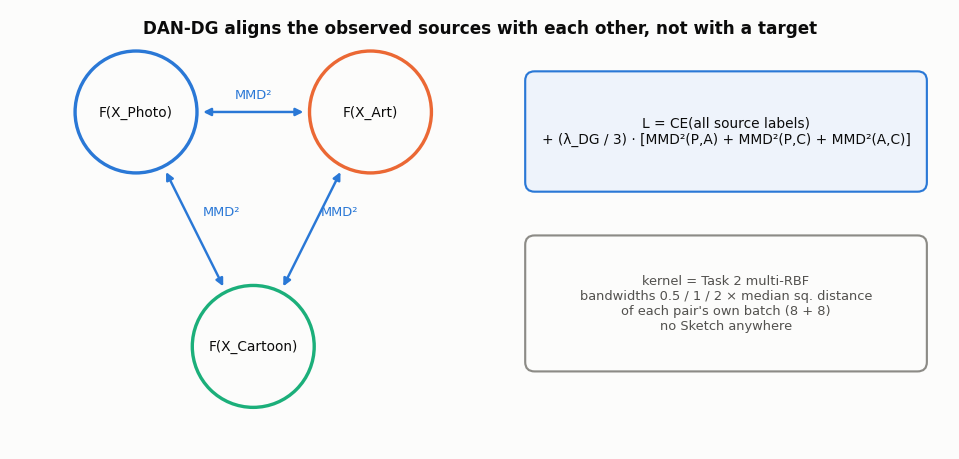

In [2]:
fig = dan_dg_diagram()
save_show(fig, os.path.join(RES, 'dan_dg_diagram.png'))

### What the MMD term sees at initialisation
One domain-balanced training batch (8 + 8 + 8) through the ImageNet-initialised ResNet-18, before any training. Left: squared feature distances **within** each domain vs **across** each domain pair, normalised by the batch median. If cross-domain distances are larger, the domains are separable, and that is what the pairwise MMD penalty pushes against. Right: the three pairwise MMD² values the loss would add on this batch.

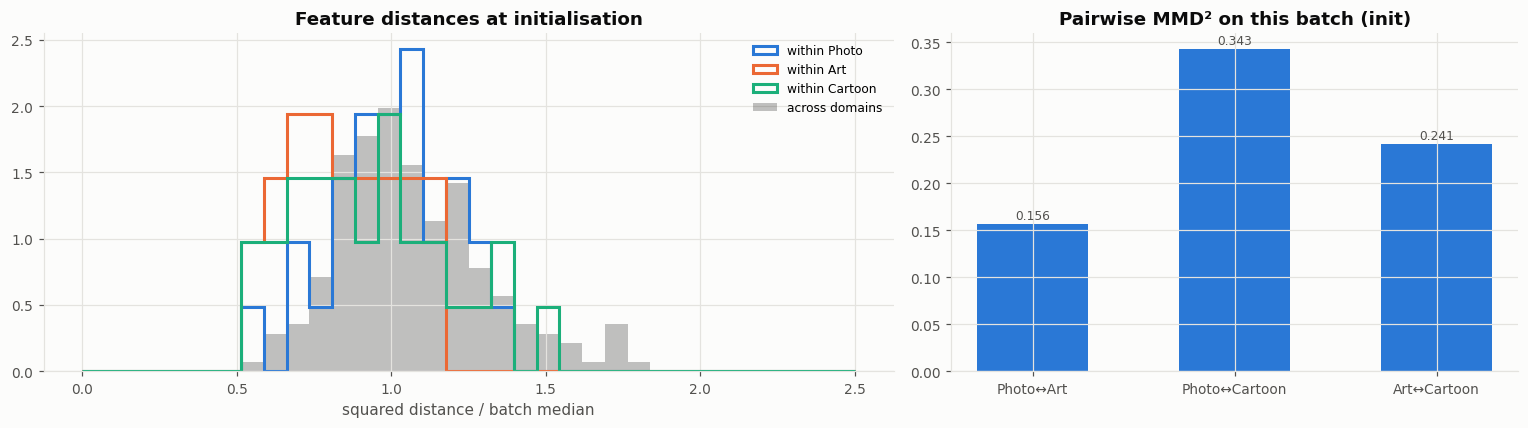

In [3]:
set_seed(SEED)
m0 = ResNet18Backbone(num_classes=7).to(device).eval()
with torch.no_grad():
    fb = {d: m0(next(iter(src_train[d]))[0].to(device))[1] for d in PACS_SOURCE_DOMAINS}
allf = torch.cat(list(fb.values())); med = torch.cdist(allf, allf).pow(2); med = med[med > 0].median().item()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [1.5, 1]})
bins = np.linspace(0, 2.5, 35)
for d in PACS_SOURCE_DOMAINS:
    dd = torch.cdist(fb[d], fb[d]).pow(2); v = (dd[dd > 0] / med).cpu().numpy()
    a1.hist(v, bins=bins, histtype='step', lw=2, color=DOMAIN_COLORS[d], density=True, label=f'within {DOM_NAMES[d]}')
pairs = [('photo', 'art_painting'), ('photo', 'cartoon'), ('art_painting', 'cartoon')]
cross = np.concatenate([(torch.cdist(fb[a], fb[b]).pow(2) / med).flatten().cpu().numpy() for a, b in pairs])
a1.hist(cross, bins=bins, histtype='stepfilled', alpha=0.25, color='#0b0b0b', density=True, label='across domains')
a1.set_xlabel('squared distance / batch median'); a1.set_title('Feature distances at initialisation'); a1.legend(fontsize=8)
vals = [compute_mmd(fb[a], fb[b]).item() for a, b in pairs]
b = a2.bar([f'{DOM_NAMES[a]}↔{DOM_NAMES[b]}' for a, b in pairs], vals, 0.55, color=PALETTE[0]); bar_labels(a2, b, fmt='{:.3f}', offset=0.002)
a2.set_title('Pairwise MMD² on this batch (init)')
fig.tight_layout(); save_show(fig, os.path.join(RES, 'dan_dg_init_distances.png'))

## 2. Train DAN-DG

In [4]:
FORCE_TRAIN = True
ckpt_path, hist_path = os.path.join(CKPT, 'dan_dg.pth'), os.path.join(CKPT, 'dan_dg_history.json')
CONFIG = dict(method='dan_dg', lambda_dg=1.0, lr=1e-4, wd=1e-4, max_epochs=MAX_EPOCHS, patience=PATIENCE, seed=SEED)
TRAIN_KW = {'method', 'lambda_dg', 'lr', 'wd', 'max_epochs', 'patience'}
if FORCE_TRAIN or not os.path.exists(ckpt_path):
    set_seed(SEED)
    out = train_dg(ResNet18Backbone(num_classes=7), src_train, src_val, device, save_path=ckpt_path, **{k: v for k, v in CONFIG.items() if k in TRAIN_KW})
    history, best_epoch, best_f1 = out['history'], out['best_epoch'], out['best_f1']
    json.dump({'config': CONFIG, 'history': history, 'best_epoch': best_epoch, 'best_f1': best_f1}, open(hist_path, 'w'), indent=1)
else:
    meta = json.load(open(hist_path)); history, best_epoch, best_f1 = meta['history'], meta['best_epoch'], meta['best_f1']
model = ResNet18Backbone(num_classes=7).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
erm = ResNet18Backbone(num_classes=7).to(device)
erm.load_state_dict(torch.load(os.path.join(T2_CKPT, 'source_only.pth'), map_location=device, weights_only=True))
erm_hist = json.load(open(os.path.join(T2_CKPT, 'source_only_history.json')))['history']
print(f"selected epoch {best_epoch} | mean source-val macro-F1 {best_f1:.4f}")

[dan_dg] ep  1 | cls 0.509 | mmd 0.0491 | val F1 mean 0.8362 worst 0.7958 *
[dan_dg] ep  2 | cls 0.198 | mmd 0.0243 | val F1 mean 0.9155 worst 0.8633 *
[dan_dg] ep  3 | cls 0.166 | mmd 0.0221 | val F1 mean 0.9242 worst 0.8937 *
[dan_dg] ep  4 | cls 0.128 | mmd 0.0143 | val F1 mean 0.9207 worst 0.8951
[dan_dg] ep  5 | cls 0.098 | mmd 0.0127 | val F1 mean 0.9020 worst 0.8445
[dan_dg] ep  6 | cls 0.081 | mmd 0.0217 | val F1 mean 0.9388 worst 0.9102 *
[dan_dg] ep  7 | cls 0.070 | mmd 0.0085 | val F1 mean 0.9392 worst 0.9160 *
[dan_dg] ep  8 | cls 0.053 | mmd 0.0121 | val F1 mean 0.9197 worst 0.8699
[dan_dg] ep  9 | cls 0.068 | mmd 0.0210 | val F1 mean 0.9360 worst 0.8990
[dan_dg] ep 10 | cls 0.057 | mmd 0.0211 | val F1 mean 0.9270 worst 0.8818
[dan_dg] ep 11 | cls 0.078 | mmd 0.0048 | val F1 mean 0.9008 worst 0.8418
[dan_dg] ep 12 | cls 0.053 | mmd 0.0131 | val F1 mean 0.9199 worst 0.8724
Early stopping at epoch 12; best epoch 7 (val F1 0.9392)
selected epoch 7 | mean source-val macro-F1 0

## 3. Training curves (ERM from Task 2 shown for reference)

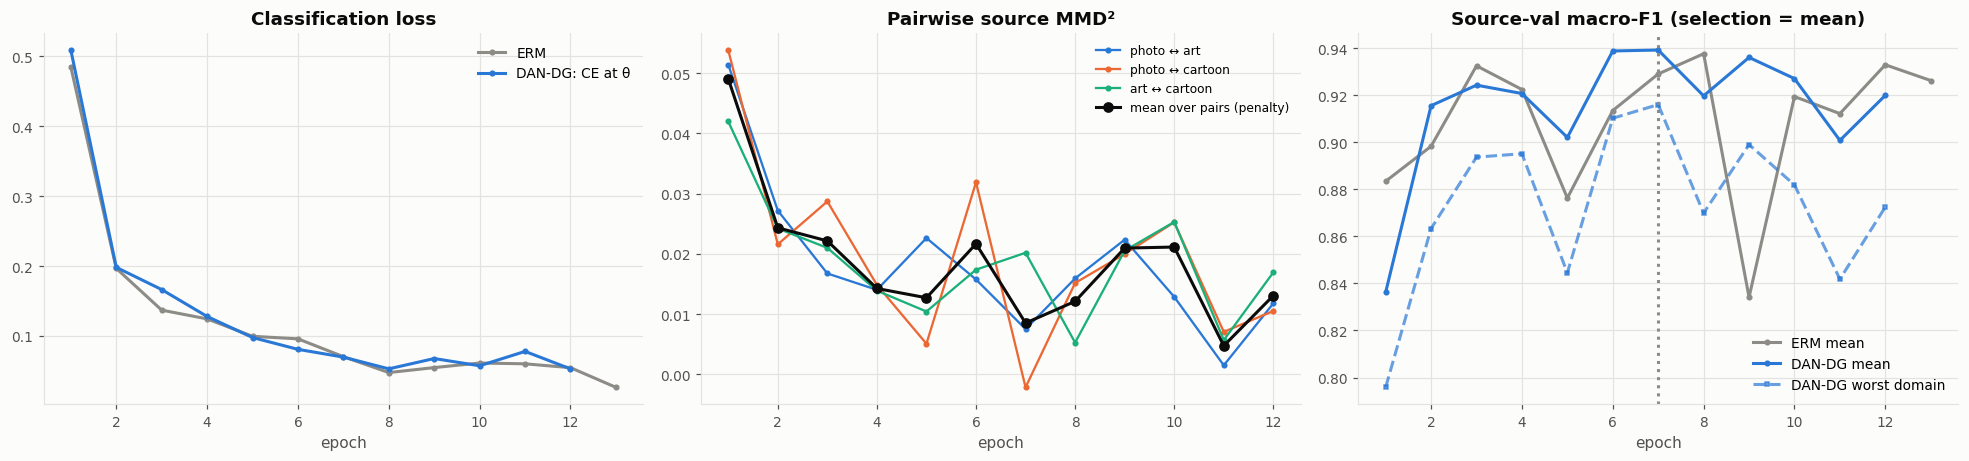

In [5]:
H = history; ep = np.arange(1, len(H['cls_loss']) + 1); e0 = np.arange(1, len(erm_hist['cls_loss']) + 1)
fig, ax = plt.subplots(1, 3, figsize=(18, 4.3))
ax[0].plot(e0, erm_hist['cls_loss'], 'o-', ms=3, color=color_of('ERM'), label='ERM')
ax[0].plot(ep, H['cls_loss'], 'o-', ms=3, color=color_of('DAN-DG'), label='DAN-DG: CE at θ')

ax[0].set_title('Classification loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
for k, v in H['mmd_pairs'].items():
    ax[1].plot(ep, v, 'o-', ms=3, lw=1.5, label=k.replace('art_painting', 'art').replace('|', ' ↔ '))
ax[1].plot(ep, H['mmd_loss'], 'o-', color='#0b0b0b', label='mean over pairs (penalty)')
ax[1].set_title('Pairwise source MMD²'); ax[1].set_xlabel('epoch'); ax[1].legend(fontsize=8)
ax[2].plot(e0, erm_hist['val_mean_f1'], 'o-', ms=3, color=color_of('ERM'), label='ERM mean')
ax[2].plot(ep, H['val_mean_f1'], 'o-', ms=3, color=color_of('DAN-DG'), label='DAN-DG mean')
ax[2].plot(ep, H['val_worst_f1'], 's--', ms=3, color=color_of('DAN-DG'), alpha=0.7, label='DAN-DG worst domain')
ax[2].axvline(best_epoch, color=NEUTRAL, ls=':'); ax[2].set_title('Source-val macro-F1 (selection = mean)'); ax[2].set_xlabel('epoch'); ax[2].legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'dan_dg_training_curves.png'))

## 4. Source-side results and diagnostics (no Sketch)
Per-domain validation performance, the source-domain separability probe (multinomial LR, C = 1, balanced features, seeded 70/30 split; chance = 33.3%), and the common sharpness proxy $\Delta_{\text{sharp}}=L_{\text{val}}(\theta+\epsilon)-L_{\text{val}}(\theta)$ with $\epsilon=0.05\,\nabla L/\|\nabla L\|$ on a fixed batch of 32 validation images per source (seed 6304, eval mode). ERM is listed for reference; notebook 4 reports all three models together.

In [6]:
xb, yb = fixed_sharpness_batch(src_val, per_domain=32, seed=SEED)
xb, yb = xb.to(device), yb.to(device)
rows = {}
for name, net in [('ERM', erm), ('DAN-DG', model)]:
    mt = evaluate_source_validation(net, src_val, device)
    r = {f'{d} F1': 100 * mt[d]['f1'] for d in PACS_SOURCE_DOMAINS}
    r.update({f'{d} acc': 100 * mt[d]['acc'] for d in PACS_SOURCE_DOMAINS})
    r['mean F1'] = np.mean([r[f'{d} F1'] for d in PACS_SOURCE_DOMAINS]); r['worst F1'] = min(r[f'{d} F1'] for d in PACS_SOURCE_DOMAINS)
    r['source separability'] = 100 * source_separability(net, src_val, device, seed=SEED)['source_separability']
    r['Δ_sharp'] = sharpness_proxy(net, xb, yb, rho=0.05)['delta_sharp']
    rows[name] = r
src_tab = pd.DataFrame(rows).T
src_tab.to_csv(os.path.join(RES, 'dan_dg_source_side.csv'))
src_tab.round(3)

,photo F1,art_painting F1,cartoon F1,photo acc,art_painting acc,cartoon acc,mean F1,worst F1,source separability,Δ_sharp
ERM,96.285,91.345,93.642,96.707,91.463,93.177,93.758,91.345,89.701,0.355
DAN-DG,97.081,91.598,93.071,97.305,91.220,92.537,93.916,91.598,70.100,0.235


## 5. Did the sources actually move together? (validation features, no Sketch)
MMD² between every pair of source domains, measured on 200 frozen **validation** features per domain (seed 6304) with the same Task 2 kernel. The left panel is ERM, the right is DAN-DG. Lower off-diagonal values mean more similar source distributions.

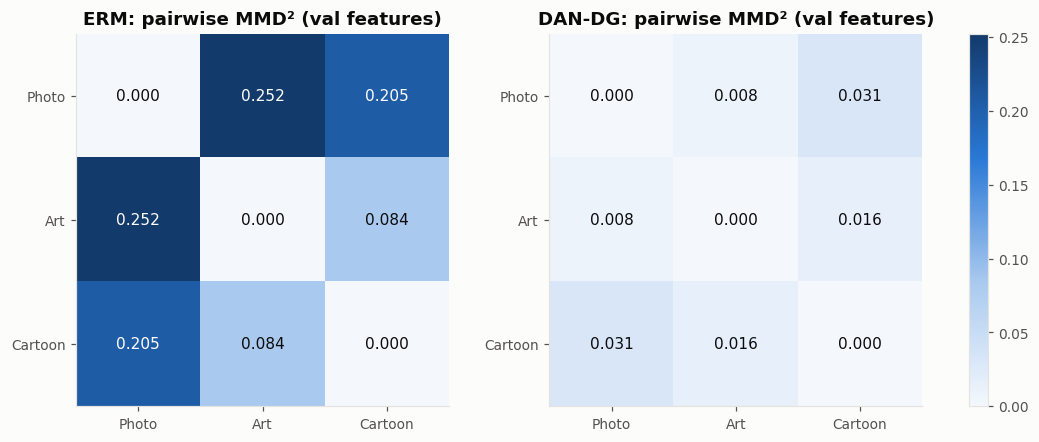

,ERM,DAN-DG
Photo↔Art,0.2525,0.0084
Photo↔Cartoon,0.2055,0.0308
Art↔Cartoon,0.0836,0.0156


In [7]:
val_out = {name: {d: collect_outputs(net, src_val[d], device) for d in PACS_SOURCE_DOMAINS} for name, net in [('ERM', erm), ('DAN-DG', model)]}
mats = {name: pairwise_mmd_matrix({d: o[d][1] for d in PACS_SOURCE_DOMAINS}, n=200, seed=SEED)[0] for name, o in val_out.items()}
vmax = max(M.max() for M in mats.values())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (name, M) in zip(axes, mats.items()):
    im = ax.imshow(M, cmap=SEQ_CMAP, vmin=0, vmax=vmax)
    for i in range(3):
        for j in range(3): ax.text(j, i, f'{M[i, j]:.3f}', ha='center', va='center', fontsize=10, color='white' if M[i, j] > 0.6 * vmax else '#0b0b0b')
    ax.set_xticks(range(3)); ax.set_xticklabels([DOM_NAMES[d] for d in PACS_SOURCE_DOMAINS]); ax.set_yticks(range(3)); ax.set_yticklabels([DOM_NAMES[d] for d in PACS_SOURCE_DOMAINS])
    ax.grid(False); ax.set_title(f'{name}: pairwise MMD² (val features)')
fig.colorbar(im, ax=axes, fraction=0.025); save_show(fig, os.path.join(RES, 'dan_dg_pairwise_mmd_matrices.png'))
pd.DataFrame({name: {f'{DOM_NAMES[a]}↔{DOM_NAMES[b]}': M[i, j] for i, a in enumerate(PACS_SOURCE_DOMAINS) for j, b in enumerate(PACS_SOURCE_DOMAINS) if i < j}
              for name, M in mats.items()}).round(4)

## 6. Source feature geometry: ERM vs DAN-DG
One t-SNE per model on all source-validation features (perplexity 30, PCA init, seed 6304). Top row: colour = domain, so it shows whether the environments were merged. Bottom row: colour = class, so it shows whether classes stayed separable after merging. Coordinates are not comparable across columns.

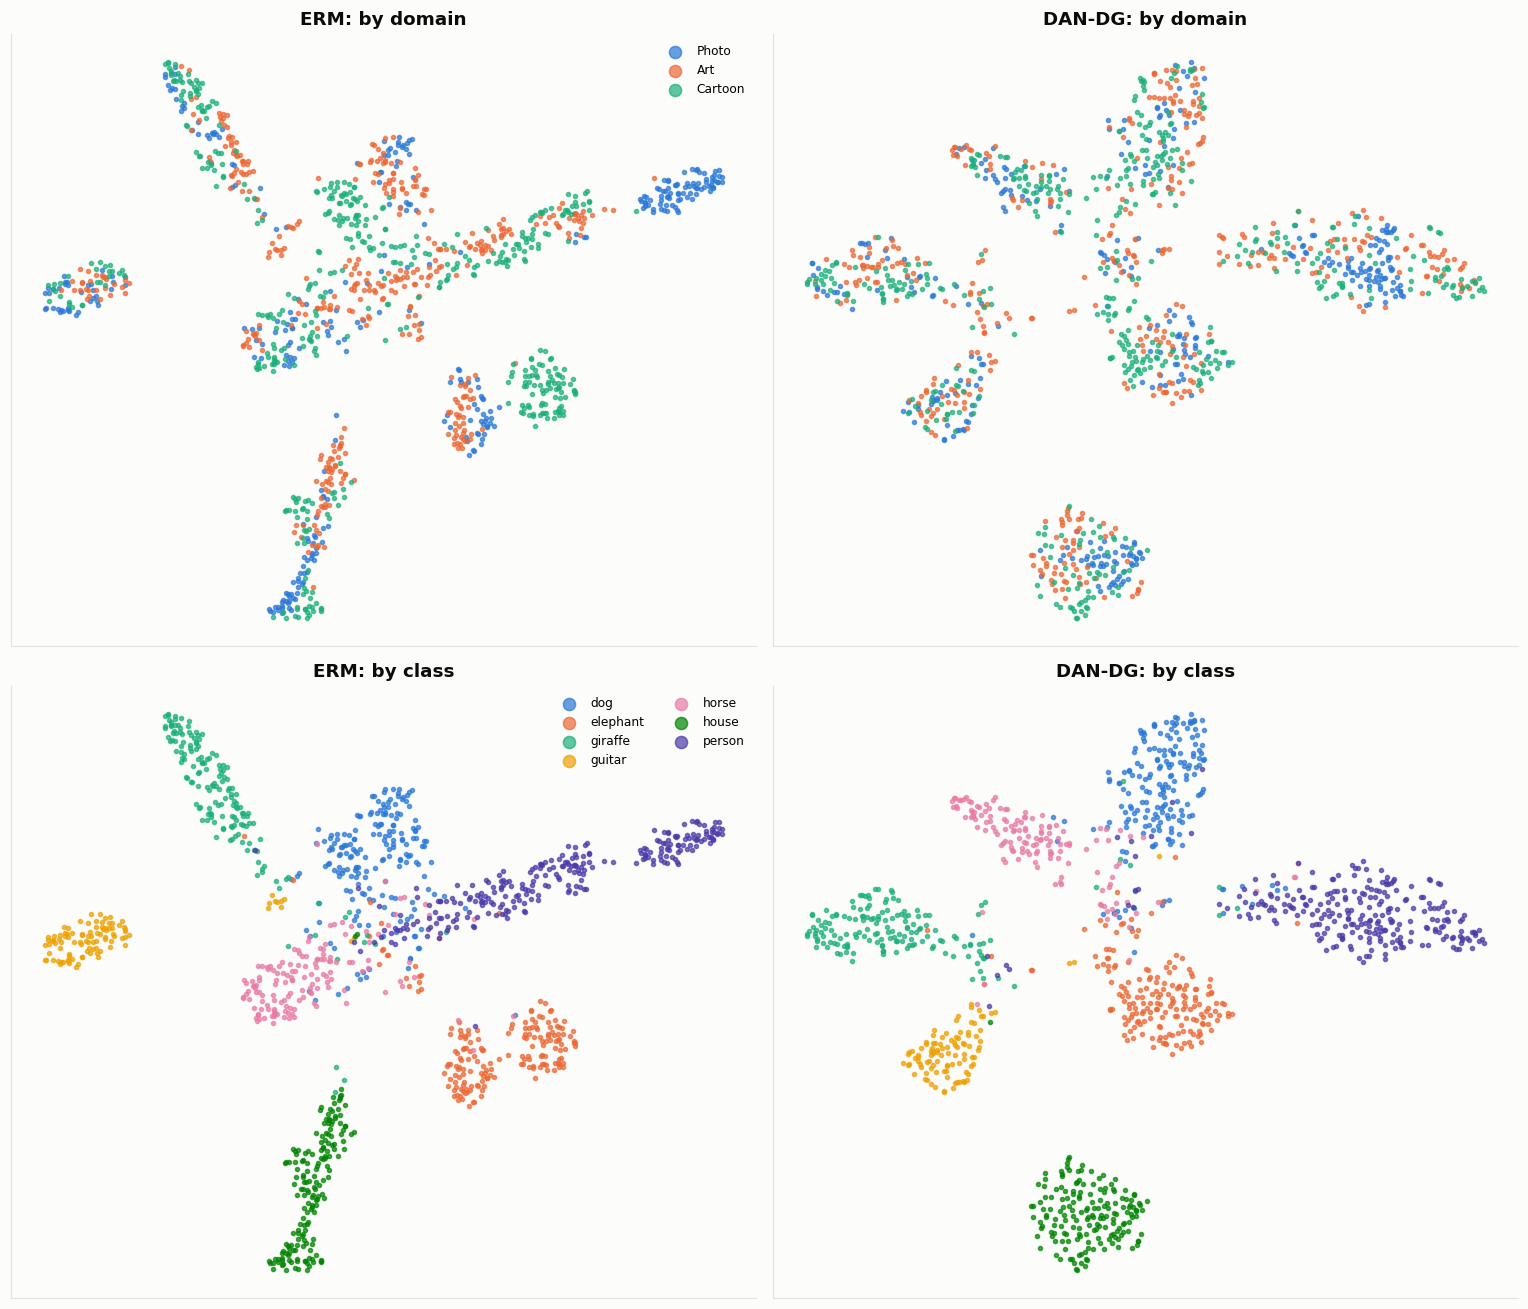

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for j, (name, o) in enumerate(val_out.items()):
    Fv = np.concatenate([o[d][1] for d in PACS_SOURCE_DOMAINS]); Yv = np.concatenate([o[d][2] for d in PACS_SOURCE_DOMAINS])
    Dv = np.concatenate([[d] * len(o[d][2]) for d in PACS_SOURCE_DOMAINS])
    E = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(Fv)
    for d in PACS_SOURCE_DOMAINS:
        axes[0, j].scatter(E[Dv == d, 0], E[Dv == d, 1], s=7, alpha=0.7, color=DOMAIN_COLORS[d], label=DOM_NAMES[d])
    for c in range(7):
        axes[1, j].scatter(E[Yv == c, 0], E[Yv == c, 1], s=7, alpha=0.7, color=PALETTE[c], label=PACS_CLASSES[c])
    axes[0, j].set_title(f'{name}: by domain'); axes[1, j].set_title(f'{name}: by class')
for a in axes.ravel(): a.set_xticks([]); a.set_yticks([])
axes[0, 0].legend(markerscale=3, fontsize=8); axes[1, 0].legend(markerscale=3, fontsize=8, ncol=2)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'dan_dg_vs_erm_tsne.png'))

## 7. Did alignment cost class information on the sources?
Per-class F1 change (DAN-DG − ERM) on each source validation split. A consistent drop in one class would suggest the marginal alignment merged it with another class. This uses source labels only.

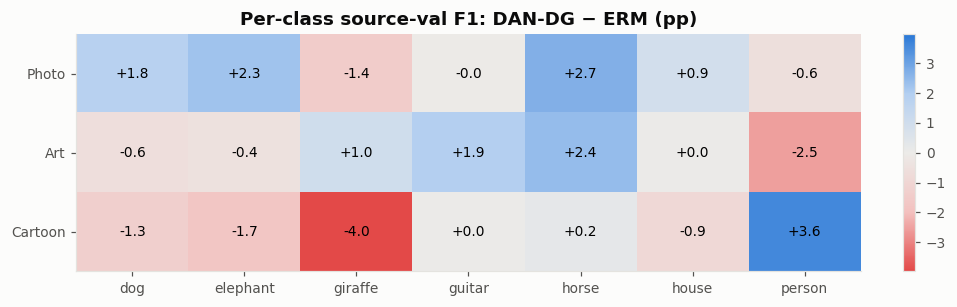

In [9]:
d_f1 = pd.DataFrame({DOM_NAMES[d]: 100 * (f1_score(val_out['DAN-DG'][d][2], val_out['DAN-DG'][d][0].argmax(1), average=None, labels=range(7))
                                           - f1_score(val_out['ERM'][d][2], val_out['ERM'][d][0].argmax(1), average=None, labels=range(7)))
                     for d in PACS_SOURCE_DOMAINS}, index=PACS_CLASSES)
lim = max(3, np.abs(d_f1.values).max())
fig, a = plt.subplots(figsize=(10, 2.8))
im = a.imshow(d_f1.T.values, cmap=DIV_CMAP, vmin=-lim, vmax=lim, aspect='auto')
for i in range(3):
    for j in range(7): a.text(j, i, f'{d_f1.T.values[i, j]:+.1f}', ha='center', va='center', fontsize=9)
a.set_xticks(range(7)); a.set_xticklabels(PACS_CLASSES); a.set_yticks(range(3)); a.set_yticklabels(d_f1.columns); a.grid(False)
a.set_title('Per-class source-val F1: DAN-DG − ERM (pp)'); fig.colorbar(im, ax=a, fraction=0.03)
save_show(fig, os.path.join(RES, 'dan_dg_source_per_class_delta.png'))